<a href="https://colab.research.google.com/github/blagaiulia/BlagaIulia-IA-1-NLP/blob/main/InvatareAutomata_Tema3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Generare date...

--- Analiza Valorilor Reale ---
K=2 -> Score: 0.6348
K=3 -> Score: 0.7860
K=4 -> Score: 0.8794
K=5 -> Score: 0.9335
K=6 -> Score: 0.8127
K=7 -> Score: 0.7020

2. Antrenare Agent (Gradient Ascent)...
Antrenare gata.

3. Rulare Test Final:
START K=2 (Scor: 0.6348)
K=2 -> Acțiune: CREȘTE -> K Nou: 3 (Scor: 0.7860)
K=3 -> Acțiune: CREȘTE -> K Nou: 4 (Scor: 0.8794)
K=4 -> Acțiune: CREȘTE -> K Nou: 5 (Scor: 0.9335)
K=5 -> Acțiune: STOP -> K Nou: 5 (Scor: 0.9335)

REZULTAT FINAL: K = 5
SUCCES! Agentul a urcat panta corect.


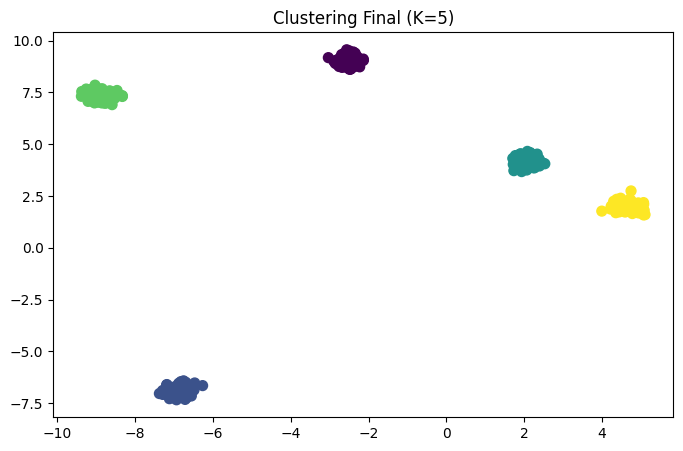

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import random

#1. GENERARE DATE
print("1. Generare date...")
data, true_labels = make_blobs(n_samples=500, centers=5, cluster_std=0.20, random_state=42)

#2. Debug
print("\n--- Analiza Valorilor Reale ---")
k_vals = range(2, 8)
scores_map = {}
for k in k_vals:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    sc = silhouette_score(data, km.fit_predict(data))
    scores_map[k] = sc
    print(f"K={k} -> Score: {sc:.4f}")

#3. MEDIUL RL BAZAT PE GRADIENT
class GradientKMeansEnv:
    def __init__(self, data):
        self.data = data
        self.min_k = 2
        self.max_k = 10
        self.current_k = 2
        # Calculăm scorul inițial pentru K=2
        km = KMeans(n_clusters=2, n_init=10, random_state=42)
        self.last_score = silhouette_score(data, km.fit_predict(data))

    def reset(self):
        self.current_k = np.random.randint(2, 4)
        km = KMeans(n_clusters=self.current_k, n_init=10, random_state=42)
        self.last_score = silhouette_score(self.data, km.fit_predict(self.data))
        return self.current_k

    def step(self, action):
        # 0: Crește K, 1: Scade K, 2: Stop
        done = False
        prev_k = self.current_k

        if action == 0: # Crește
            self.current_k = min(self.max_k, self.current_k + 1)
        elif action == 1: # Scade
            self.current_k = max(self.min_k, self.current_k - 1)
        elif action == 2: # Stop
            done = True
            return self.current_k, 0, done, self.last_score


        if self.current_k == prev_k:
            return self.current_k, -5, False, self.last_score

        # Calculăm NOUL scor
        kmeans = KMeans(n_clusters=self.current_k, n_init=10, random_state=42)
        labels = kmeans.fit_predict(self.data)
        current_score = silhouette_score(self.data, labels)

        reward = (current_score - self.last_score) * 100

        self.last_score = current_score

        return self.current_k, reward, done, current_score

#4. ANTRENARE
print("\n2. Antrenare Agent (Gradient Ascent)...")
env = GradientKMeansEnv(data)
q_table = np.zeros((12, 3))

alpha = 0.1
gamma = 0.8
epsilon = 1.0
epsilon_decay = 0.99
episodes = 1000

for episode in range(episodes):
    state = env.reset()
    done = False

    while not done:
        if random.uniform(0, 1) < epsilon:
            action = random.randint(0, 2)
        else:
            action = np.argmax(q_table[state])

        next_state, reward, done, score = env.step(action)

        old_val = q_table[state, action]
        next_max = np.max(q_table[next_state])
        q_table[state, action] = (1 - alpha) * old_val + alpha * (reward + gamma * next_max)

        state = next_state

    epsilon = max(0.01, epsilon * epsilon_decay)

print("Antrenare gata.")

#5. TESTARE FINALĂ
print("\n3. Rulare Test Final:")
state = env.reset()
state = 2
env.current_k = 2
km_start = KMeans(n_clusters=2, n_init=10, random_state=42)
env.last_score = silhouette_score(data, km_start.fit_predict(data))

done = False
steps = 0
path = [state]

print(f"START K={state} (Scor: {env.last_score:.4f})")

while not done and steps < 10:
    action = np.argmax(q_table[state])

    act_str = ["CREȘTE", "SCADE", "STOP"][action]

    next_state, reward, done, score = env.step(action)

    print(f"K={state} -> Acțiune: {act_str} -> K Nou: {next_state} (Scor: {score:.4f})")

    if not done:
        path.append(next_state)
        state = next_state
    steps += 1

print(f"\nREZULTAT FINAL: K = {path[-1]}")
if path[-1] == 5:
    print("SUCCES! Agentul a urcat panta corect.")
else:
    print("Eroare.")

# Vizualizare
final_km = KMeans(n_clusters=path[-1], n_init=10, random_state=42)
plt.figure(figsize=(8, 5))
plt.scatter(data[:, 0], data[:, 1], c=final_km.fit_predict(data), s=50, cmap='viridis')
plt.title(f"Clustering Final (K={path[-1]})")
plt.show()